In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
from scipy import stats

### Question 1
Converting a probability into a 'sigma'. As discussed in class, 'sigma' refers to a probability in physics. Our first task is to figure out how, given a probability, to calculate the assoicated 'sigma' value. The sigma implicitly refers to the standard normal distribution (a Gaussian with mean zero and standard deviation of 1). As we discussed in class, integrals of the standard normal distribution give probabilities.

#### Part (a)
Look up the Normal distribution and read about it. A few potential starting points: Math is fun, Wolfram, and a useful z table

#### Part (b) 
As in class, try integrating the standard normal distribution. This can be done either with the erfc(), or calls to specific statistical cumulative probability distributions such as stats.norm.cdf() in scipy. Try several values of sigma, and make sure you are getting values that match the z-table.

In [2]:
#Making a function for calculating zscore
def z_score(x, mean, sigma):
    result = (x - mean) / sigma
    return result

In [3]:
#Measurement of 1 from mu = 3, sigma = 2
print(stats.norm.cdf(1, 3, 2))       
print(z_score(1, 3, 2))                #zscore of -1.0; probability of 0.15866

#Measurement of -20 from mu = 3, sigma = 17
print(stats.norm.cdf(-20, 3, 17)) 
print(z_score(-20, 3, 17))             #zscore of -1.35; probability of 0.08851

0.15865525393145707
-1.0
0.08803721170291773
-1.3529411764705883


#### Part (c)
Now more often than not, we actually want to do the inverse: for a given probability determine the associated 'sigma' value: stats.norm.ppf() in python. Try several probability values where you know what the answer should be (e.g. Probability associated with 1, 2, 5 sigma), and show that you get the right answer in terms of sigma.

In [4]:
#Making a function for calculating x
def x_value(z_score, mean, sigma):
    result = z_score * sigma + mean
    return result

In [5]:
#One sigma away (looking for x = 1)
print(stats.norm.ppf((1 - .682) / 2, 3, 2)) 
print(x_value(-1.0, 3, 2))                           #probability of 0.15866; z-score of -1.0

#Two sigma away (looking for -1.0)
print(stats.norm.ppf((1 - .954) / 2, 3, 2)) 
print(x_value(-2.0, 3, 2))                           #probability of 0.02275; z-score of -2.0    

#Five sigma away (looking for -7.0)
print(stats.norm.ppf(2.9 * 10 **(-7), 3, 2))
print(x_value(-5.0, 3, 2))                              #probability of 2.86652×10−7; z-score of -5.0

1.0028474587686806
1.0
-0.990786620335649
-1.0
-6.995520718360895
-7.0


#### Part (d)
If a minus sign appears, think about it and explain the meaning.

If a minus sign appears in the z-score, the x-value is less than the mean. The probability is less than 50% (taking the integral from -$\infty$ to $x$)

### Question 2
Now let's explore some other continuous analytic distributions. Following the pattern from your first HW assigment, make both the analytic pdf() and a realization with ~100k samples using a built-in distribution; but this time don't use the Gaussian. Choose one of the following distributions: Rayleigh; Lognormal; Chi-Squared or Gamma; Exponential. You and your partner should choose different distributions.

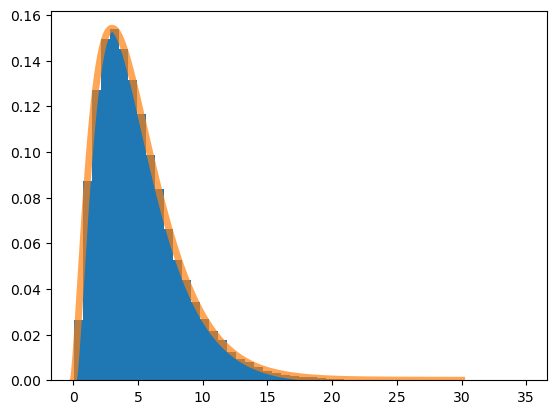

In [6]:
#Base
my_d1 = stats.chi2.rvs(5, loc = 0, scale = 1, size = 100000)

fig, ax = plt.subplots(1, 1)
ax.hist(my_d1, 50, density = True)
x = np.linspace(0, 30, 100000)
ax.plot(x, stats.chi2.pdf(x, 5, loc = 0, scale = 1), linewidth = 5,alpha = 0.7)
plt.show()

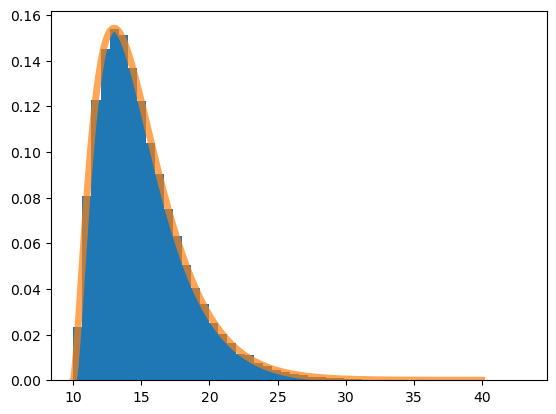

In [7]:
#Changing loc (changes "start" of distribution) 
my_d2 = stats.chi2.rvs(5, loc = 10, scale = 1, size = 100000)

fig, ax = plt.subplots(1, 1)
ax.hist(my_d2, 50, density = True)
x = np.linspace(10, 40, 100000)
ax.plot(x, stats.chi2.pdf(x, 5, loc = 10, scale = 1), linewidth = 5, alpha = 0.7)
plt.show()

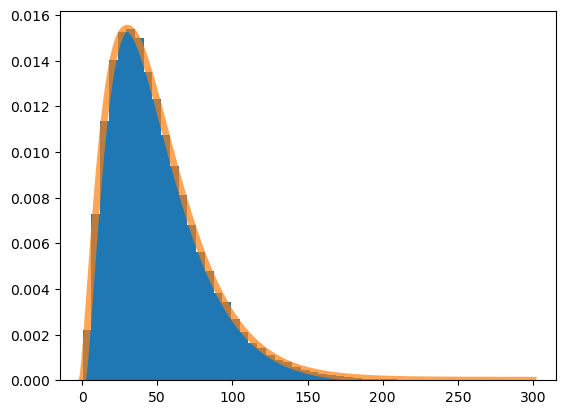

In [8]:
#Changing scale (changes spread of distribution)
my_d2 = stats.chi2.rvs(5, loc = 0, scale = 10, size = 100000)

fig, ax = plt.subplots(1, 1)
ax.hist(my_d2, 50, density = True)
x = np.linspace(0, 300, 100000)
ax.plot(x, stats.chi2.pdf(x, 5, loc = 0, scale = 10), linewidth = 5, alpha = 0.7)
plt.show()

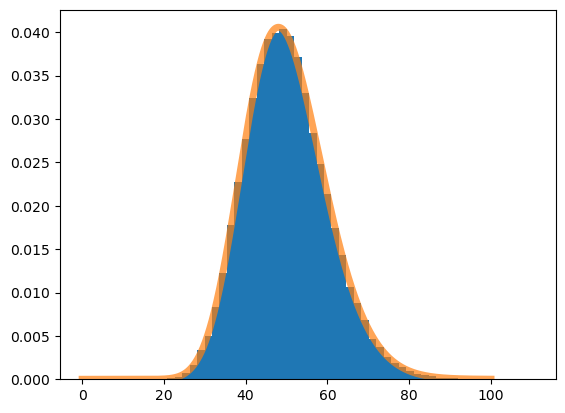

In [9]:
#Changing df (make it closer to normal looking)
my_d2 = stats.chi2.rvs(50, loc = 0, scale = 1, size = 100000)

fig, ax = plt.subplots(1, 1)
ax.hist(my_d2, 50, density = True)
x = np.linspace(0, 100, 100000)
ax.plot(x, stats.chi2.pdf(x, 50, loc = 0, scale = 1), linewidth = 5,alpha = 0.7)
plt.show()

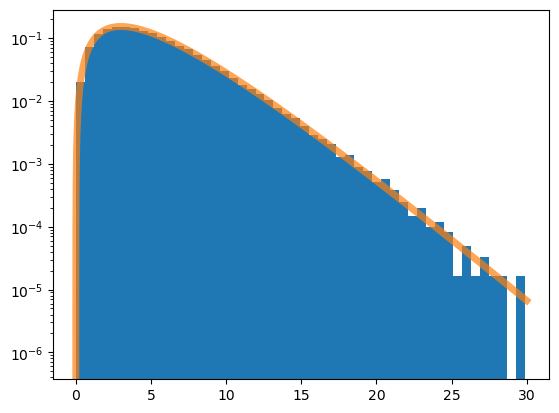

In [10]:
#Base in log scale
my_d1 = stats.chi2.rvs(5, loc = 0, scale = 1, size = 100000)

fig, ax = plt.subplots(1, 1)
ax.hist(my_d1, 50, density = True)
plt.yscale('log')
x = np.linspace(0, 30, 100000)
ax.plot(x, stats.chi2.pdf(x, 5, loc = 0, scale = 1), linewidth = 5,alpha = 0.7)
plt.show()

### Question 3
Imagine that your signal-free data follows the distribution you have chosen; and you have a measurement for which you need to determine the 'sigma'
Clearly state the statistical question you want to ask in words
Convert your word question into a mathematical integral
Use the math to calculate the probability that the background produced the signal (Hint: you will want to use the statistics functions to do the integrals. .cdf() and .ppf() in scipy).
Convert your probability into an equivalent 'sigma'

#### Part (a)
Select a value for your hypothetical measurement

My measurement will be 7.

#### Part (b)
Clearly state the statistical question you want to ask in words

What is the probability that the background noise produces the measurement of 7 or greater given that it follows a chi2 distribution (df = 5)?

#### Part (c)
Convert your word question into a mathematical integral

$$ P(x \geq 7) = \int_{7}^{\infty} \frac{x^{1.5} \ e^{-x / 2}}{2^{2.5} \ \Gamma(2.5)} \,dx\ $$ 

#### Part (d)
Use the math to calculate the probability that the background produced the signal

In [11]:
prob_7 = 1 - stats.chi2.cdf(7, 5, loc = 0, scale = 1)
f"The probability that the background produced the signal is {prob_7:.5f} given that the background follows a chi2 distribution (df = 5)."

'The probability that the background produced the signal is 0.22064 given that the background follows a chi2 distribution (df = 5).'

#### Part (e)
Convert your probability into an equivalent 'sigma'

In [12]:
print(stats.norm.ppf(prob_7, 0, 1))  

-0.7700324972925833


### Question 4
Now explore a little bit. Try various hypothetical measurement values and see how the probabilities and 'sigmas' change. Discuss the patterns that you see.

In [13]:
#Hypothetical measurement of 1
prob_1 = 1 - stats.chi2.cdf(1, 5, loc = 0, scale = 1)
sigma_1 = stats.norm.ppf(prob_1, 0, 1)
print(f"For a measurement of 1, the probability is {prob_1:.5f}. The equivalent 'sigma' is {sigma_1:.5f}.")

#Hypothetical measurement of 3
prob_3 = 1 - stats.chi2.cdf(3, 5, loc = 0, scale = 1)
sigma_3 = stats.norm.ppf(prob_3, 0, 1)
print(f"For a measurement of 3, the probability is {prob_3:.5f}. The equivalent 'sigma' is {sigma_3:.5f}.")

#Hypothetical measurement of 5
prob_5 = 1 - stats.chi2.cdf(5, 5, loc = 0, scale = 1)
sigma_5 = stats.norm.ppf(prob_5, 0, 1)
print(f"For a measurement of 5, the probability is {prob_5:.5f}. The equivalent 'sigma' is {sigma_5:.5f}.")

#Hypothetical measurement of 15
prob_15 = 1 - stats.chi2.cdf(15, 5, loc = 0, scale = 1)
sigma_15 = stats.norm.ppf(prob_15, 0, 1)
print(f"For a measurement of 15, the probability is {prob_15:.5f}. The equivalent 'sigma' is {sigma_15:.5f}.")

For a measurement of 1, the probability is 0.96257. The equivalent 'sigma' is 1.78127.
For a measurement of 3, the probability is 0.69999. The equivalent 'sigma' is 0.52436.
For a measurement of 5, the probability is 0.41588. The equivalent 'sigma' is -0.21244.
For a measurement of 15, the probability is 0.01036. The equivalent 'sigma' is -2.31296.


As the measurement reaches a probability of 50%, the sigma will likely hit 0. A negative sigma corresponds to a probability less than 50% while a positive sigma corresponds to a probability greater than 50%. It's mapping the probability onto the standard normal distribution $N(0, 1)$ and sigma gives you the probability of getting that x-value (on the normal distribution) or less.